In [1]:
from IPython.display import display, HTML
display(HTML("<style>.jp-Cell { margin-left: -20% !important; margin-right: -10% !important; }</style>"))

In [17]:
import pandas as pd
pd.set_option('display.max_rows', 10000)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)


import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

import folium
from folium import plugins

data=pd.read_csv('C:\\Users\\victor.maltsev\\Тестирование\\Стройсервис\\КС_1982\\route5\\21_w.csv',sep=';',encoding='cp1251')
data.drop('Unnamed: 0',axis=1,inplace=True)
display(data.head(3))

,len,Скорость,Широта,Долгота,Вес мгновенный,Продольный наклон,Поперечный наклон,Высота,"Уровень топлива, литры","Уровень топлива, проценты",путь,ДВС.Расход топлива,Ускорение по оси X,Ускорение по оси Y,Ускорение по оси Z,Статус самосвала,Самосвал,Модель самосвала,Грузоподъемность,Обороты двигателя,Расчетный выходной крутящий момент двигателя (в процентах от эталонного),Текущая нагрузка двигателя,Давление в левой передней шине,Температура в левой передней шине,Давление в правой передней шине,Температура в правой передней шине,Давление в левой задней внешней шине,Температура в левой задней внешней шине,Давление в левой задней внутренней шине,Температура в левой задней внутренней шине,Давление в правой задней внутренней шине,Температура в правой задней внутренней шине,Давление в правой задней внешней шине,Температура в правой задней внешней шине,Расход топлива,Давление левый передний цилиндр,Давление правый передний цилиндр,Давление левый задний цилиндр,Давление правый задний цилиндр,уклон,azimut,isin_border,Давление левый передний цилиндр_,Давление правый передний цилиндр_,Давление левый задний цилиндр_,Давление правый задний цилиндр_,point,nom_point,"уровень давления впереди,МПа","уровень давления сзади,МПа",рекомендованная скорость_turns,Поворот влево,Поворот вправо,centr,radius,подъем,спуск,рекомендованная скорость_min,рекомендованная скорость_max
0,0.0,8.0,53.723655,86.841991,214.0,7.605083,3.607378,-0.079365,NaN,94.0,0.000000,436.375,0.128480,-0.922810,-0.124401,Груженный движется вперед,95,7530G,240,1820.0,94.0,100.0,804.0,27.0,800.0,27.0,876.0,43.0,892.0,41.0,8.0,43.0,856.0,47.0,0.484861,2.5,6.1,9.9,14.4,8.580427,1.036518,0,5.5,5.5,10.1,14.645,point_30%,1,5.5,10.1,0,0,0,-,0,0,0,0.0,0.0
1,11.0,7.0,53.723740,86.842076,218.0,5.822628,1.876247,1.232580,NaN,94.0,10.929891,425.700,-0.022433,-1.019680,-0.104007,Груженный движется вперед,95,7530G,240,1763.0,98.0,100.0,804.0,27.0,800.0,27.0,876.0,43.0,892.0,41.0,8.0,43.0,856.0,47.0,0.957861,5.6,3.3,8.8,11.4,7.769994,1.174722,0,5.5,5.5,10.1,10.100,-,0,5.5,10.1,0,0,0,-,0,0,0,0.0,0.0
2,21.0,10.0,53.723827,86.842137,223.0,9.101636,0.474801,2.621894,NaN,94.0,10.533861,440.075,-0.032630,-0.973284,-0.156011,Груженный движется вперед,95,7530G,240,1814.0,95.0,100.0,804.0,27.0,800.0,27.0,876.0,43.0,892.0,41.0,8.0,43.0,856.0,47.0,1.324590,3.5,4.2,12.6,9.8,7.159821,1.443493,0,5.5,5.5,10.1,10.100,-,0,5.5,10.1,0,0,0,-,0,0,0,0.0,0.0


## Лабораторная работа 1

In [ ]:
#from sklearn import svm
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

data=pd.read_csv('C:\\Users\\victor.maltsev\\Тестирование\\Стройсервис\\КС_1982\\route5\\21_w.csv',sep=';',encoding='cp1251')
data.drop('Unnamed: 0',axis=1,inplace=True)

#print(data.columns)
X = data[['Скорость','Ускорение по оси X', 'Ускорение по оси Y', 'Ускорение по оси Z']].values.tolist()
print(X[:10])

data['point']=data['point'].apply(lambda x:'0' if x=='-' else '30' if x=='point_30%' else '60' if x=='point_60%' else '90' if x=='point_90%' else '120' if x=='point_120%' else '150') 
y=data['point'].tolist()

print(y)

clf = make_pipeline(StandardScaler(), SVC(kernel='rbf',gamma='auto',decision_function_shape='ovo'))

#clf = SVC(kernel='rbf',gamma='auto', decision_function_shape='ovo')
clf.fit(X, y)

dec = clf.decision_function(X)
print(dec[:10])
y_predict=clf.predict(X)
print(y_predict)
#Формула расчёта: Precision = TP / (TP + FP), где: 
#TP (True Positive) — верно предсказанные положительные случаи;
#FP (False Positive) — отрицательные случаи, ошибочно предсказанные как положительные.
tp=0
fp=0
for i in range(len(y)):
    if (y[i]!='0')&(y_predict[i]!='0'):
        tp+=1
    elif (y[i]=='0')&(y_predict[i]!='0'):
        fp+=1
if tp+fp>0:
    print('precision for hole','\n','tp=',tp,' fp=',fp,' precision=',tp/(tp+fp))
else:
    print('precision for hole','\n','tp=',tp,' fp=',fp,' precision=0')
tp=0
fp=0
for i in range(len(y)):
    if (y[i]=='30')&(y_predict[i]=='30'):
        tp+=1
    elif (y[i]!='30')&(y_predict[i]=='30'):
        fp+=1
if tp+fp>0:
    print('precision for 30%','\n','tp=',tp,' fp=',fp,' precision=',tp/(tp+fp))
else:
    print('precision for 30%','\n','tp=',tp,' fp=',fp,' precision=0')
tp=0
fp=0
for i in range(len(y)):
    if (y[i]=='60')&(y_predict[i]=='60'):
        tp+=1
    elif (y[i]!='60')&(y_predict[i]=='60'):
        fp+=1
if tp+fp>0:
    print('precision for 60%','\n','tp=',tp,' fp=',fp,' precision=',tp/(tp+fp))
#Recall = TP / (TP + FN)
fn=0
tp=0
for i in range(len(y)):
    if (y[i]!='0')&(y_predict[i]!='0'):
        tp+=1
    elif (y[i]=='0')&(y_predict[i]!='0'):
        fn+=1
if tp+fn>0:
    print('recall for hole','\n','tp=',tp,' fn=',fn,' precision=',tp/(tp+fn))
else:
    print('recall for hole','\n','tp=',tp,' fn=',fn,' precision=0')

data['xy']=data.apply(lambda x:[x['Широта'],x['Долгота']],axis=1)
#display(data[['Широта','Долгота','Высота','xy']].head(3))
m = folium.Map (data.loc[0,'xy'], zoom_start = 13)
title_html = '''<h3 align="center" style="font-size:21px"><b>{}</b></h3>'''.format('Тест')
m.get_root().html.add_child(folium.Element(title_html))
route = folium.PolyLine (list(data['xy']),вес = 3, color = 'green', непрозрачность = 0.8).add_to (m)
#    route = folium.PolyLine (list(way_pole['xy']),вес = 3, color = 'blue', непрозрачность = 0.8).add_to (m)
for i in range(len(y)):
    if y[i]=='30':
        folium.CircleMarker(location=data.loc[i,'xy'], radius =2, popup=str(i)+'_'+str(data.loc[i,'len']),
                            fill_color='green',color='green',fill_opacity = 0.9).add_to(m)
    if y_predict[i]=='30':
        folium.CircleMarker(location=data.loc[i,'xy'], radius =3, popup=str(i)+'_'+str(data.loc[i,'len']),
                            fill_color='red',color='red',fill_opacity = 0.9).add_to(m)           
display(m)
print('accuracy_score',accuracy_score(y,y_predict))
y_30=[0 for i in range(len(y))]
y_30_predict=[0 for i in range(len(y))]    
for i in range(len(y)):
    if y[i]=='30':
        y_30[i]=1
    if y_predict[i]=='30':
        y_30_predict[i]=1

print(y_30,y_30_predict)    
print('precision =', precision_score(y_30, y_30_predict))
print('recall =', recall_score(y_30, y_30_predict))

### Траектория движения на карте

In [ ]:
data['xy']=data.apply(lambda x:[x['Широта'],x['Долгота']],axis=1)
#display(data[['Широта','Долгота','Высота','xy']].head(3))
ind=data[data['point'].str.contains('point')].index.tolist()
m = folium.Map (data.loc[0,'xy'], zoom_start = 13)
title_html = '''<h3 align="center" style="font-size:21px"><b>{}</b></h3>'''.format('Тест')
m.get_root().html.add_child(folium.Element(title_html))
route = folium.PolyLine (list(data['xy']),вес = 3, color = 'green', непрозрачность = 0.8).add_to (m)
#    route = folium.PolyLine (list(way_pole['xy']),вес = 3, color = 'blue', непрозрачность = 0.8).add_to (m)
for i in ind:
    if '30' in data.loc[i,'point']:
        folium.CircleMarker(location=data.loc[i,'xy'], radius =2, popup=str(i)+'_'+str(data.loc[i,'len']),
                            fill_color='blue',color='blue',fill_opacity = 0.9).add_to(m)
    else:
        folium.CircleMarker(location=data.loc[i,'xy'], radius =3, popup=str(i)+'_'+str(data.loc[i,'len']),
                            fill_color='red',color='red',fill_opacity = 0.9).add_to(m)           
display(m)




### График скорости

In [ ]:
fig = make_subplots(specs=[[{"secondary_y": True}]])
#fig.add_trace(go.Scatter(x=data['len'], y=data['Уровень топлива, проценты'],mode='lines', name='уровень data'),secondary_y=False)
#fig.add_trace(go.Scatter(x=data1['len'], y=data1['Уровень топлива, проценты'],mode='lines', name='уровень data1'),secondary_y=False)
fig.add_trace(go.Scatter(x=data['len'], y=data['Скорость'],mode='lines', name='Скорость'),secondary_y=False)
fig.add_trace(go.Scatter(x=data['len'], y=data['Высота'],mode='lines', name='Высота'),secondary_y=True)
#fig.add_trace(go.Scatter(x=data['len'], y=data['Скорость_'],mode='lines', name='Скорость_'),secondary_y=True)
#fig.add_trace(go.Scatter(x=data1['len'], y=data1['Скорость'],mode='lines', name='Скорость1'),secondary_y=True)
name='21_w'
fig.update_layout(title_text='Скорость для маршрута '+name)

### Лабораторная работа 3

In [12]:
import pandas as pd
pd.set_option('display.max_rows', 10000)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

import folium
from folium import plugins

data_1=pd.read_csv('53_w.csv',sep=';',encoding='cp1251')
#data_1.drop('Unnamed: 0',axis=1,inplace=True)
data_1['xy']=data_1.apply(lambda x:[x['Широта'],x['Долгота']],axis=1)
data_2=pd.read_csv('5_w.csv',sep=';',encoding='cp1251')
#data_2.drop('Unnamed: 0',axis=1,inplace=True)
data_2['xy']=data_2.apply(lambda x:[x['Широта'],x['Долгота']],axis=1)
#display(data[['Широта','Долгота','Высота','xy']].head(3))

m = folium.Map (data_1.loc[0,'xy'], zoom_start = 13)
title_html = '''<h3 align="center" style="font-size:21px"><b>{}</b></h3>'''.format('Тест')
m.get_root().html.add_child(folium.Element(title_html))
route = folium.PolyLine (list(data_1['xy']),вес = 3, color = 'green', непрозрачность = 0.8).add_to (m)
route = folium.PolyLine (list(data_2['xy']),вес = 3, color = 'blue', непрозрачность = 0.8).add_to (m)
for i in range(len(data_1)):
    folium.CircleMarker(location=data_1.loc[i,'xy'], radius =2, popup=str(i),fill_color='red',color='red',fill_opacity = 0.9).add_to(m)
folium.CircleMarker(location=[60.200465, 60.372604], radius =2, popup='Старая Сама',fill_color='purple',color='red',fill_opacity = 0.9).add_to(m)
folium.CircleMarker(location=[60.219981, 60.403563], radius =3, popup='Денежкино',fill_color='purple',color='red',fill_opacity = 0.9).add_to(m)         
display(m)

lat1=60.200465
lon1=60.372604
lat2=60.219981
lon2=60.403563
lat1_rad = np.radians(lat1)
lon1_rad = np.radians(lon1)
lat2_rad = np.radians(lat2)
lon2_rad = np.radians(lon2)

dlon = lon2_rad - lon1_rad
 
y = np.sin(dlon) * np.cos(lat2_rad)
x = np.cos(lat1_rad) * np.sin(lat2_rad) - np.sin(lat1_rad) * np.cos(lat2_rad) * np.cos(dlon)

az_rad = np.arctan2(y, x)
az_deg = np.degrees(az_rad)

# Normalize to [0, 360) degrees
az_deg = (az_deg + 360) % 360
we_rad=np.arctan((lat2_rad-lat1_rad)/(lon2_rad-lon1_rad))
we_deg=np.degrees(we_rad)
we_deg=(we_deg + 360) % 360
print (f"az_deg: {az_deg}")
EARTH_RADIUS = 6371000  # in meters
# Haversine formula
dlat = lat2_rad - lat1_rad
dlon = lon2_rad - lon1_rad
a = np.sin(dlat/2) * np.sin(dlat/2) + np.cos(lat1_rad) *np.cos(lat2_rad) * np.sin(dlon/2) * np.sin(dlon/2)
c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))
distance = EARTH_RADIUS * c
 
    
print('az_deg=',az_deg,' we_rad=',we_rad,' we_deg=',we_deg,' distance=',distance)
def azimut(x):
    lat1_rad = np.radians(x['Широта'])
    lon1_rad = np.radians(x['Долгота'])
    lat2_rad = np.radians(x['Широта_'])
    lon2_rad = np.radians(x['Долгота_'])
    dlon = lon2_rad - lon1_rad
    y = np.sin(dlon) * np.cos(lat2_rad)
    x = np.cos(lat1_rad) * np.sin(lat2_rad) - np.sin(lat1_rad) * np.cos(lat2_rad) * np.cos(dlon)
    az_rad = np.arctan2(y, x)
    az_deg = np.degrees(az_rad)
    # Normalize to [0, 360) degrees and return
    return((az_deg + 360) % 360)
def dist(x):
    lat1_rad = np.radians(x['Широта'])
    lon1_rad = np.radians(x['Долгота'])
    lat2_rad = np.radians(x['Широта_'])
    lon2_rad = np.radians(x['Долгота_'])
    EARTH_RADIUS = 6371000  # in meters
    # Haversine formula
    dlat = lat2_rad - lat1_rad
    dlon = lon2_rad - lon1_rad
    a = np.sin(dlat/2) * np.sin(dlat/2) + np.cos(lat1_rad) *np.cos(lat2_rad) * np.sin(dlon/2) * np.sin(dlon/2)
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))
    distance = EARTH_RADIUS * c
    # Normalize to [0, 360) degrees and return
    return(EARTH_RADIUS * c)
data_1['Широта_']=data_1['Широта'].shift(-1)
data_1['Долгота_']=data_1['Долгота'].shift(-1)
data_1.loc[len(data_1)-1,'Широта_']=data_1.loc[len(data_1)-1,'Широта']
data_1.loc[len(data_1)-1,'Долгота_']=data_1.loc[len(data_1)-1,'Долгота']

data_1['azimut']=data_1.apply(lambda x:azimut(x),axis=1)
data_1['dist']=data_1.apply(lambda x:dist(x),axis=1)
data_1['s_a_v']=data_1.apply(lambda x: x['Скорость']+np.sqrt(x['Ускорение по оси Z']**2+x['Ускорение по оси X']**2)*9.81/2,axis=1)
display(data_1[['Широта','Широта_','Долгота','Долгота_','azimut','путь','dist','Скорость','Ускорение по оси X','Ускорение по оси Y','Ускорение по оси Z','s_a_v']][255:178])


az_deg: 38.229050920039015
az_deg= 38.229050920039015  we_rad= 0.5624602441039207  we_deg= 32.2265981310527  distance= 2763.0319471850908


,Широта,Широта_,Долгота,Долгота_,azimut,путь,dist,Скорость,Ускорение по оси X,Ускорение по оси Y,Ускорение по оси Z,s_a_v


### Азимут по ускорению

In [19]:

#data['azimut_a_xy']=data.apply(lambda x: np.arctan(x['Ускорение по оси X']/x['Ускорение по оси Z']),axis=1)
data['azimut_a']=data.apply(lambda x: np.arctan(x['Ускорение по оси Z']/x['Ускорение по оси X']),axis=1)
data['s_a']=data.apply(lambda x: np.sqrt(x['Ускорение по оси Z']**2+x['Ускорение по оси X']**2)*9.81*9.81,axis=1)
data['s_v']=data.apply(lambda x: x['Скорость'],axis=1)
display(data[['len','Скорость','Широта','Долгота','Высота','путь','Ускорение по оси X','Ускорение по оси Y','Ускорение по оси Z','azimut','azimut_a','s_a','s_v']])

,len,Скорость,Широта,Долгота,Высота,путь,Ускорение по оси X,Ускорение по оси Y,Ускорение по оси Z,azimut,azimut_a,s_a,s_v
0,0.0,8.0,53.723655,86.841991,-0.079365,0.000000,0.128480,-0.922810,-0.124401,1.036518,-0.769271,17.210560,8.0
1,11.0,7.0,53.723740,86.842076,1.232580,10.929891,-0.022433,-1.019680,-0.104007,1.174722,1.358364,10.239433,7.0
2,21.0,10.0,53.723827,86.842137,2.621894,10.533861,-0.032630,-0.973284,-0.156011,1.443493,1.364618,15.338759,10.0
3,32.0,10.0,53.723925,86.842158,4.083184,10.998496,0.019374,-0.941164,-0.156011,1.442101,-1.447246,15.129216,10.0
4,43.0,11.0,53.724023,86.842180,5.611056,11.034141,-0.080555,-1.003875,-0.116243,1.654522,0.964796,13.610388,11.0
5,56.0,13.0,53.724135,86.842164,7.200118,12.522993,-0.028551,-0.994188,-0.117263,1.298674,1.331965,11.614631,13.0
6,67.0,14.0,53.724232,86.842210,8.844975,11.199142,-0.031610,-1.015601,-0.110125,1.533101,1.291274,11.025988,14.0
7,89.0,16.0,53.724424,86.842222,10.540234,21.322059,-0.072397,-1.028857,-0.088712,1.386506,0.886320,11.019436,16.0
8,105.0,14.0,53.724573,86.842269,12.280502,16.929215,-0.035689,-1.002345,-0.122362,1.523227,1.287002,12.266251,14.0
9,121.0,14.0,53.724712,86.842280,14.060385,15.513485,-0.016315,-0.998267,-0.101968,1.490325,1.412141,9.937814,14.0


### Удаление выбросов

In [ ]:
def smooth_velocity(dat):
    dat['Скорость_']=dat['Скорость'].apply(lambda x:np.NaN if x<0.2 else x)
    dat['Скорость_']=dat['Скорость_'].interpolate(limit_direction='both')
    return dat
data=smooth_velocity(data)
fig = make_subplots(specs=[[{"secondary_y": True}]])

fig.add_trace(go.Scatter(x=data['len'], y=data['Скорость'],mode='lines', name='Скорость'),secondary_y=False)
fig.add_trace(go.Scatter(x=data['len'], y=data['Скорость_'],mode='lines', name='Скорость_'),secondary_y=False)
fig.add_trace(go.Scatter(x=data['len'], y=data['Давление левый передний цилиндр'],mode='lines', name='Давление'),secondary_y=True)

fig.update_layout(title_text='Скорость  и давление для маршрута '+name)

In [ ]:
def draw(df,tag,fig,nom):
    tag_=tag+'_'
    med=df[tag].mean()
    print('med=',med)
    df['med']=med
    df['median']=data[tag].median()
        
    fig.add_trace(go.Scatter(x=df['len'], y=df[tag],mode='lines', name='Давление'+nom),secondary_y=True)
    fig.add_trace(go.Scatter(x=df['len'], y=df[tag_],mode='lines', name='Давление_'+nom),secondary_y=True)
    fig.add_trace(go.Scatter(x=df['len'], y=df['med'],mode='lines', name='Среднее давление'+nom),secondary_y=True)
    fig.add_trace(go.Scatter(x=df['len'], y=df['median'],mode='lines', name='Медиана давление'+nom),secondary_y=True)
    fig.add_trace(go.Scatter(x=df['len'], y=df['Скорость'],mode='lines', name='Скорость'+nom),secondary_y=False)
    fig.update_layout(title_text='Скорость и давление для маршрута '+tag, autosize=False, width=1450, height=700)
    return fig
    
fig = make_subplots(specs=[[{"secondary_y": True}]])    
tag='Давление левый задний цилиндр'
fig=draw(data,tag,fig,'21')

fig.show()


In [ ]:
ind=data[data['point'].str.contains('point')].index.tolist()
print(ind)

In [ ]:
from typing import List, Dict, Tuple

import torch
import torchvision.transforms as T
from torch.utils.data import Dataset, SequentialSampler

from src.aimotive_dataset import AiMotiveDataset
from src.data_loader import DataItem
from src.loaders.camera_loader import CameraData
from src.loaders.lidar_loader import LidarData
from src.loaders.radar_loader import RadarData

CATEGORY_MAPPING = {'CAR': 0, 'Size_vehicle_m': 0,
                    'TRUCK': 1, 'BUS': 1, 'TRUCK/BUS': 1, 'TRAIN': 1, 'Size_vehicle_xl': 1, 'VAN': 1,
                    'PICKUP': 1,
                    'MOTORCYCLE': 2, 'RIDER': 2, 'BICYCLE': 2, 'BIKE': 2, 'Two_wheel_without_rider': 2,
                    'Rider': 2,
                    'OTHER_RIDEABLE': 2, 'OTHER-RIDEABLE': 2,
                    'PEDESTRIAN': 3, 'BABY_CARRIAGE': 3
                    }

crop = T.CenterCrop(size=(704, 1280))
to_tensor = T.ToTensor()

class AiMotiveTorchDataset(Dataset):
    """
    PyTorch Dataset for loading data to PyTorch framework.
    """
    def __init__(self, root_dir: str, train: bool = True, max_objects: int = 30, max_lidar_points: int = 150_000,
                 max_radar_targets: int = 100):
        data_split = 'train' if train else 'val'
        self.dataset = AiMotiveDataset(root_dir, data_split)
        self.max_objects = max_objects
        self.max_lidar_points = max_lidar_points
        self.max_radar_targets = max_radar_targets

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, index):
        data_item = self.dataset.data_loader[self.dataset.dataset_index[index]]
        sensor_data = self.get_sensor_data(data_item)
        annotations = self.get_targets(data_item.annotations.objects, CATEGORY_MAPPING)
        annotations = self.prepare_annotations(annotations)

        return sensor_data, annotations

    def get_sensor_data(self, data_item: DataItem) -> List:
        lidar_data, radar_data, camera_data = data_item.lidar_data, data_item.radar_data, data_item.camera_data

        lidar_data = self.prepare_lidar_data(lidar_data)
        front_radar_data, back_radar_data = self.prepare_radar_data(radar_data)
        front_cam, back_cam, left_cam, right_cam = self.prepare_camera_data(camera_data)

        sensor_data = [lidar_data, [front_radar_data, back_radar_data], [front_cam, back_cam, left_cam, right_cam]]

        return sensor_data

    def get_targets(self, annotations: List[Dict], category_mapping: Dict[str, int]):
        # Generate your custom target representation here.
        targets = []
        for obj in annotations:
            x, y, z = [obj[f'BoundingBox3D Origin {ax}'] for ax in ['X', 'Y', 'Z']]
            l, w, h = [obj[f'BoundingBox3D Extent {ax}'] for ax in ['X', 'Y', 'Z']]
            vel_x, vel_y, vel_z = [obj[f'Relative Velocity {ax}'] for ax in ['X', 'Y', 'Z']]
            q_w, q_x, q_y, q_z = [obj[f'BoundingBox3D Orientation Quat {ax}'] for ax in ['W', 'X', 'Y', 'Z']]
            cat = category_mapping[obj['ObjectType']]

            targets.append(torch.tensor([[cat, x, y, z, l, w, h, q_w, q_x, q_y, q_z, vel_x, vel_y, vel_z]]))

        return targets

    def prepare_lidar_data(self, lidar_data: LidarData) -> torch.tensor:
        lidar_data = torch.from_numpy(lidar_data.top_lidar.point_cloud)
        lidar_data = self.pad_data(lidar_data, self.max_lidar_points, lidar_data.shape[1])

        return lidar_data

    def prepare_radar_data(self, radar_data: RadarData) -> Tuple[torch.tensor, torch.tensor]:
        front_radar_data = torch.from_numpy(radar_data.front_radar.point_cloud)
        back_radar_data = torch.from_numpy(radar_data.back_radar.point_cloud)

        front_radar_data = self.pad_data(front_radar_data, self.max_radar_targets, front_radar_data.shape[1])
        back_radar_data = self.pad_data(back_radar_data, self.max_radar_targets, back_radar_data.shape[1])

        return front_radar_data, back_radar_data

    def prepare_camera_data(self, camera_data: CameraData) -> Tuple[torch.tensor, torch.tensor, torch.tensor, torch.tensor]:
        front_cam = crop(to_tensor(camera_data.front_camera.image))
        back_cam = crop(to_tensor(camera_data.back_camera.image))
        left_cam = crop(to_tensor(camera_data.left_camera.image))
        right_cam = crop(to_tensor(camera_data.right_camera.image))

        return front_cam, back_cam, left_cam, right_cam

    def pad_data(self, data: torch.tensor, max_items: int, attributes: int) -> torch.tensor:
        if len(data) > max_items:
            data = data[:max_items]
            return data
        else:
            padded_data = torch.zeros([max_items, attributes])
            padded_data[:data.shape[0], :] = data

        return padded_data

    def prepare_annotations(self, annotations: torch.tensor) -> torch.tensor:
        if len(annotations) > self.max_objects:
            annotations = annotations[:self.max_objects]
        else:
            pad = self.max_objects - len(annotations)
            for i in range(pad):
                annotations.append(torch.zeros(14))

        annotations = torch.vstack(annotations)

        return annotations

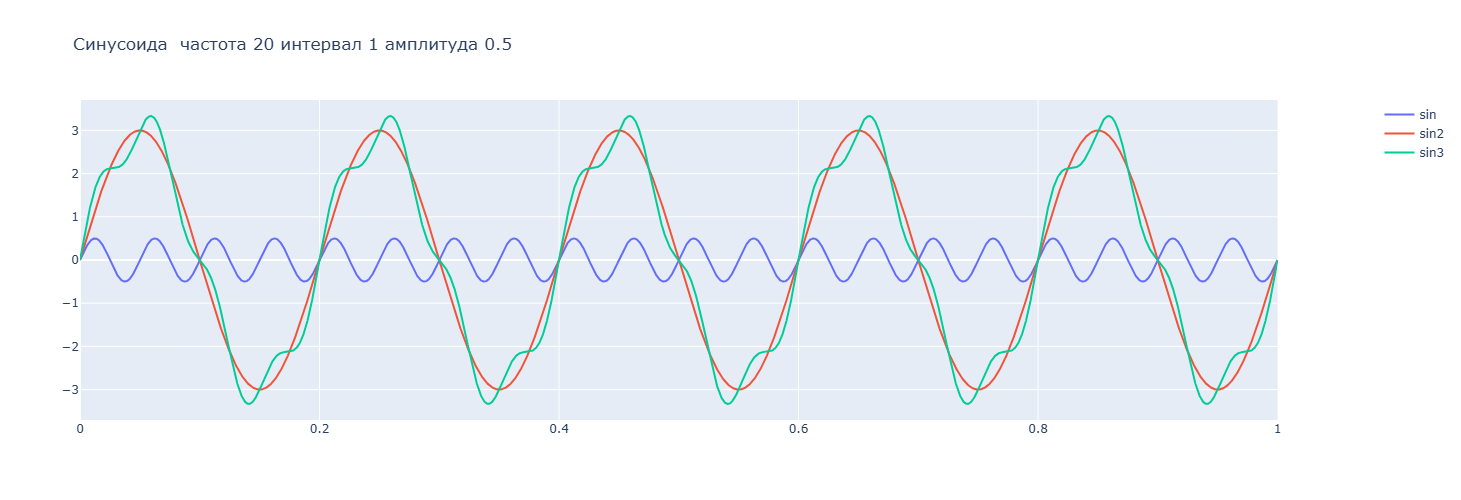

 1


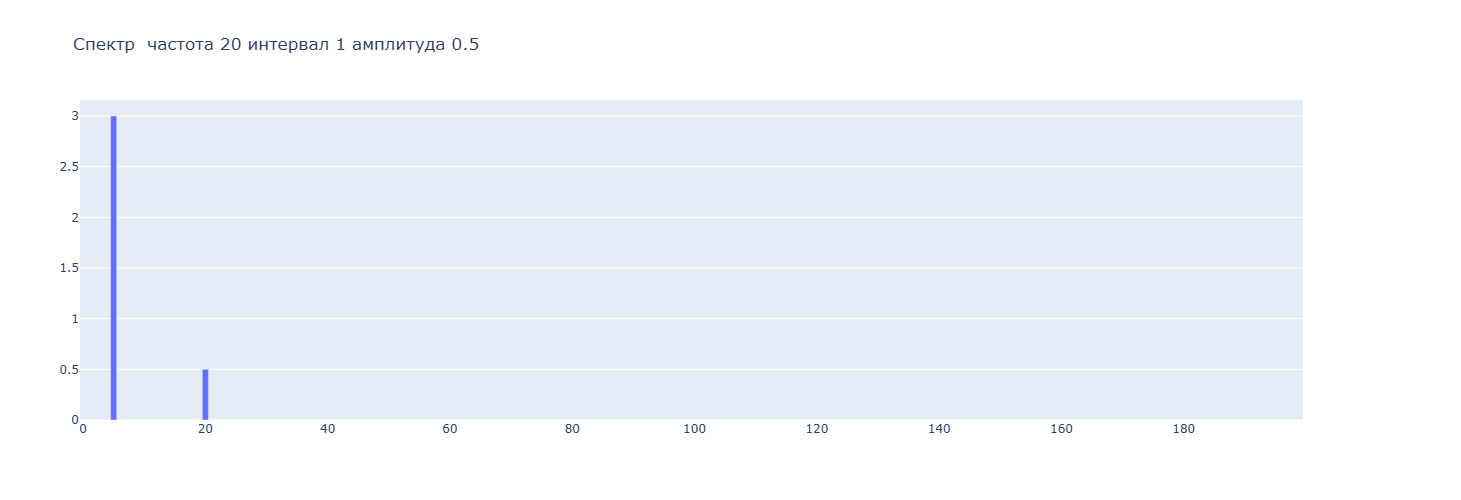

In [11]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np
from scipy.fft import fft, ifft, fftfreq, irfft, rfft, rfftfreq
def _sin(freq,interval,ampl,x,par):
    n_p=interval*freq*par
    if len(x)==0:
        x=[interval/n_p*i for i in range(n_p+1)]
    y=[ampl*np.sin(2*3.1415926*j*freq) for j in x]
    return x,y
_parameter_N=1000
_freq=20
_interval=1
_ampl=.5
_x,_y=_sin(_freq,_interval,_ampl,[],_parameter_N)

_,__y=_sin(5,_interval,3,_x,_parameter_N)
___y=[_y[i]+__y[i] for i in range(len(_x))]


fig = make_subplots(specs=[[{"secondary_y": True}]])
fig.add_trace(go.Scatter(x=_x, y=_y,mode='lines', name='sin'),secondary_y=False)
name='частота '+str(_freq)+' интервал '+str(_interval)+' амплитуда '+str(_ampl)
fig.add_trace(go.Scatter(x=_x, y=__y,mode='lines', name='sin2'),secondary_y=False)
fig.add_trace(go.Scatter(x=_x, y=___y,mode='lines', name='sin3'),secondary_y=False)
fig.update_layout(title_text='Синусоида  '+name,width=1200,height=500)
fig.show()
fft_res = rfft(___y) / len(_y) * 2
frequency = list(map(lambda x: round(x, 2), rfftfreq(len(_y), 1/_freq/_parameter_N)))

abs_fft_res=[abs(fft_res[i]) for i in range(len(fft_res))] 

input()
fig = make_subplots(specs=[[{"secondary_y": True}]])
fig.add_trace(go.Bar(x=frequency[:200], y=abs_fft_res[:200],width=1, name='spectr'),secondary_y=False)
name='частота '+str(_freq)+' интервал '+str(_interval)+' амплитуда '+str(_ampl)
fig.update_layout(title_text='Спектр  '+name,width=1200,height=500)
fig.show()

In [13]:
#print(fft_res[:20]) 
print(frequency[:20])
print(abs_fft_res[:20])

[0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0, 13.0, 14.0, 15.0, 16.0, 17.0, 18.0, 19.0]
[1.3392206785756254e-10, 6.497730947143747e-05, 0.00014783963784676017, 0.00028877929335245026, 0.0006766661028481068, 2.9999380465450276, 0.0008016124631520554, 0.00041746239627791566, 0.0002838085628361376, 0.00021280004392534705, 0.00016662104371493967, 0.00013241356916925666, 0.00010436056870381203, 7.912490799449448e-05, 5.417656472306989e-05, 2.6797838767086247e-05, 7.1802502764295195e-06, 5.6486481502212065e-05, 0.00014636527946478478, 0.00040172033360641663]


In [3]:
import pandas as pd
pd.set_option('display.max_rows', 10000)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

import folium
from folium import plugins

data_1=pd.read_csv('../lab_1/1_w.csv',sep=';',encoding='cp1251')
#data_1.drop('Unnamed: 0',axis=1,inplace=True)
data_1['xy']=data_1.apply(lambda x:[x['Широта'],x['Долгота']],axis=1)
data_2=pd.read_csv('../lab_1/1_w.csv',sep=';',encoding='cp1251')
#data_2.drop('Unnamed: 0',axis=1,inplace=True)
data_2['xy']=data_2.apply(lambda x:[x['Широта'],x['Долгота']],axis=1)
#display(data[['Широта','Долгота','Высота','xy']].head(3))

m = folium.Map (data_1.loc[0,'xy'], zoom_start = 13)
title_html = '''<h3 align="center" style="font-size:21px"><b>{}</b></h3>'''.format('Тест')
m.get_root().html.add_child(folium.Element(title_html))
route = folium.PolyLine (list(data_1['xy']),вес = 3, color = 'green', непрозрачность = 0.8).add_to (m)
route = folium.PolyLine (list(data_2['xy']),вес = 3, color = 'blue', непрозрачность = 0.8).add_to (m)
for i in range(len(data_1)):
    folium.CircleMarker(location=data_1.loc[i,'xy'], radius =2, popup=str(i),fill_color='red',color='red',fill_opacity = 0.9).add_to(m)
folium.CircleMarker(location=[55.431136,37.544997], radius =2, popup='новокузнецк',fill_color='red',color='red',fill_opacity = 0.9).add_to(m)
folium.CircleMarker(location=[55.755864,37.617698], radius =3, popup='Прокопьевск',fill_color='red',color='red',fill_opacity = 0.9).add_to(m)         
display(m)

lat2=55.431136
lon2=37.544997
lat1=55.755864
lon1=37.617698
lat1_rad = np.radians(lat1)
lon1_rad = np.radians(lon1)
lat2_rad = np.radians(lat2)
lon2_rad = np.radians(lon2)

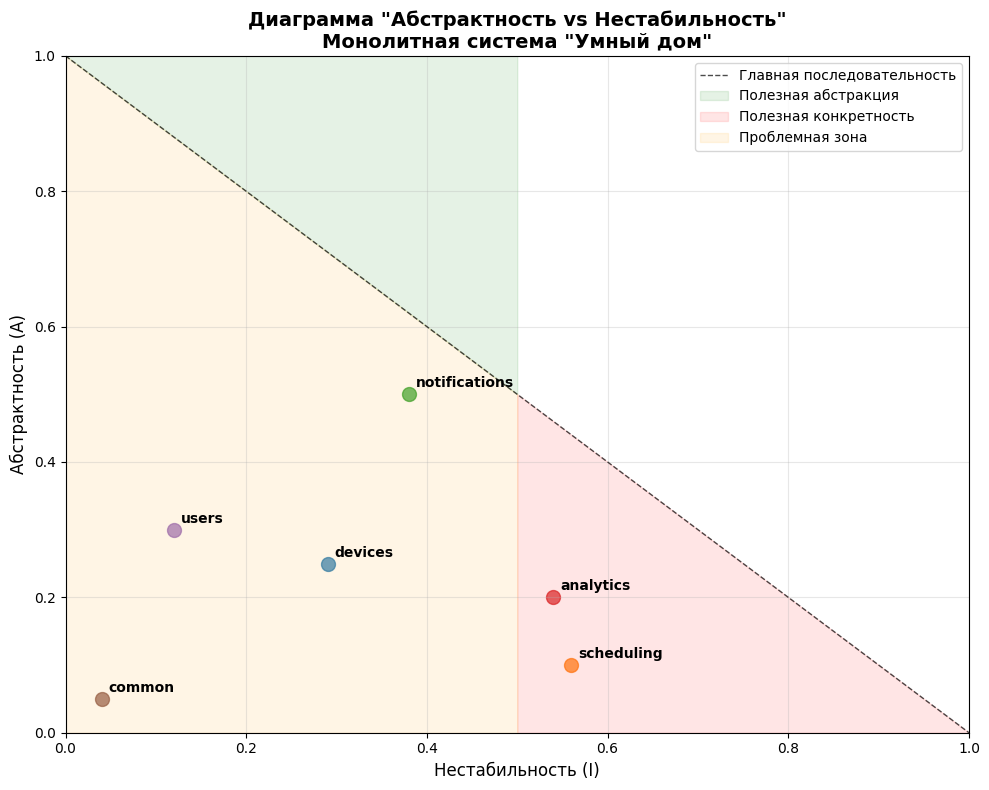


Анализ положения модулей относительно главной последовательности:
----------------------------------------------------------------------
devices         | Нестабильность: 0.29 | Абстрактность: 0.25 | Расстояние: 0.33
scheduling      | Нестабильность: 0.56 | Абстрактность: 0.10 | Расстояние: 0.24
notifications   | Нестабильность: 0.38 | Абстрактность: 0.50 | Расстояние: 0.08
analytics       | Нестабильность: 0.54 | Абстрактность: 0.20 | Расстояние: 0.18
users           | Нестабильность: 0.12 | Абстрактность: 0.30 | Расстояние: 0.41
common          | Нестабильность: 0.04 | Абстрактность: 0.05 | Расстояние: 0.64


In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Данные модулей: (нестабильность, абстрактность, название)
modules = [
    (0.29, 0.25, "devices"),
    (0.56, 0.10, "scheduling"),
    (0.38, 0.50, "notifications"),
    (0.54, 0.20, "analytics"),
    (0.12, 0.30, "users"),
    (0.04, 0.05, "common")
]

# Создаем фигуру
plt.figure(figsize=(10, 8))

# Рисуем главную последовательность (пунктирная линия)
x_main = np.array([0, 1])
y_main = 1 - x_main  # A = 1 - I
plt.plot(x_main, y_main, 'k--', alpha=0.7, linewidth=1, label='Главная последовательность')

# Рисуем точки для каждого модуля
for i, (x, y, name) in enumerate(modules):
    plt.scatter(x, y, s=100, alpha=0.7)
    plt.annotate(name, (x, y), xytext=(5, 5), textcoords='offset points', 
                fontsize=10, fontweight='bold')

# Добавляем зоны
plt.fill_between([0, 0.5], [1, 0.5], [1, 1], alpha=0.1, color='green', label='Полезная абстракция')
plt.fill_between([0.5, 1], [0.5, 0], [0, 0], alpha=0.1, color='red', label='Полезная конкретность')
plt.fill_between([0, 0.5], [0, 0], [1, 0.5], alpha=0.1, color='orange', label='Проблемная зона')

# Настройки графика
plt.xlabel('Нестабильность (I)', fontsize=12)
plt.ylabel('Абстрактность (A)', fontsize=12)
plt.title('Диаграмма "Абстрактность vs Нестабильность"\nМонолитная система "Умный дом"', fontsize=14, fontweight='bold')

plt.xlim(0, 1)
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

# Дополнительная информация о модулях
print("\nАнализ положения модулей относительно главной последовательности:")
print("-" * 70)
for x, y, name in modules:
    distance = abs(x + y - 1) / np.sqrt(2)  # расстояние до прямой A + I = 1
    print(f"{name:15} | Нестабильность: {x:.2f} | Абстрактность: {y:.2f} | Расстояние: {distance:.2f}")